# **Plot Module**

In [1]:
from yaiv import plot
print(plot.__doc__)


YAIV | yaiv.plot

This module provides plotting utilities for visualizing eigenvalue spectra from periodic
systems. It supports electronic and vibrational spectra obtained from common ab initio
codes such as Quantum ESPRESSO and VASP.

Functions in this module are designed to work seamlessly with spectrum-like objects
(e.g., `Spectrum`, `ElectronBands`, `PhononBands`) and accept units-aware data.

The visualizations are based on `matplotlib`, and include options for:

- Plotting band structures and phonon spectra
- Automatically shifting eigenvalues (e.g., Fermi level)
- Detecting and patching discontinuities in the k-path
- Annotating high-symmetry points from KPOINTS or bands.in

Functions
---------
get_HSP_ticks(kpath, k_lattice=None)
    Computes tick positions and LaTeX labels for high-symmetry points along a k-path.

kpath(ax, kpath, k_lattice=None)
    Plots vertical lines and labels at high-symmetry points in a matplotlib Axes.

bands(electronBands, ax=None, ...)
    Plots the

---
>*The **documentation** of every function is accesible with the usual **shift + tab** shortcut.*
---

# Examples

In [1]:
from yaiv import plot
from yaiv import spectrum
import matplotlib.pyplot as plt

## Electronic bands

### Single spectrum plots

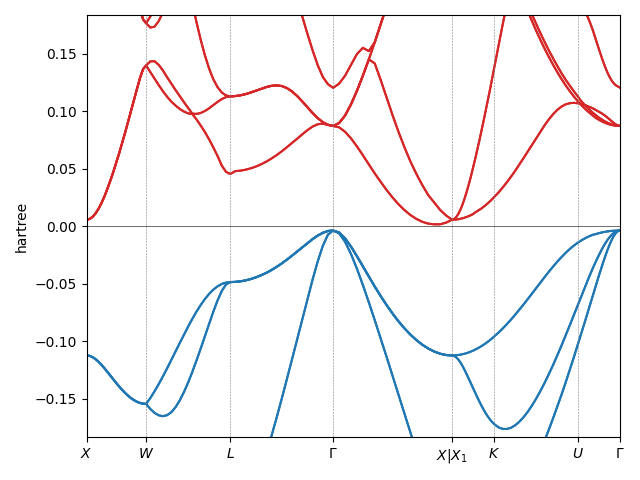

In [18]:
bands=spectrum.ElectronBands('data/qe/results_bands/bands.xml')
bands.kpath=grep.kpath('data/qe/results_bands/Si.bands.pwi')
ax=plot.bands(bands,
           window=[-5,5]*ureg.eV)

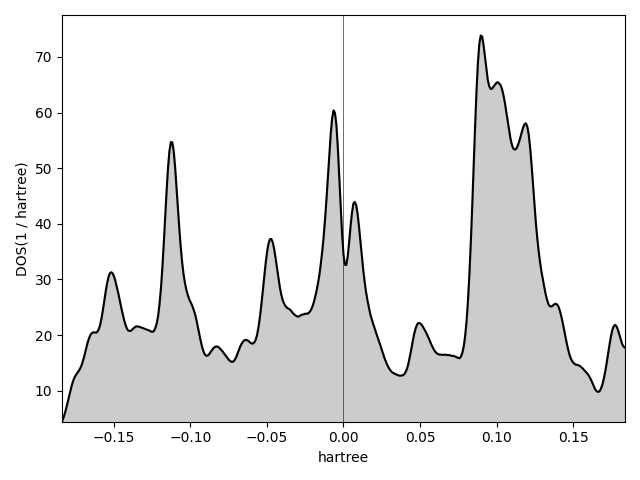

In [19]:
bands=spectrum.ElectronBands('data/qe/results_bands/bands.xml')
ax=plot.DOS(bands,
           window=[-5,5]*ureg.eV,
           smearing=100*ureg.meV)

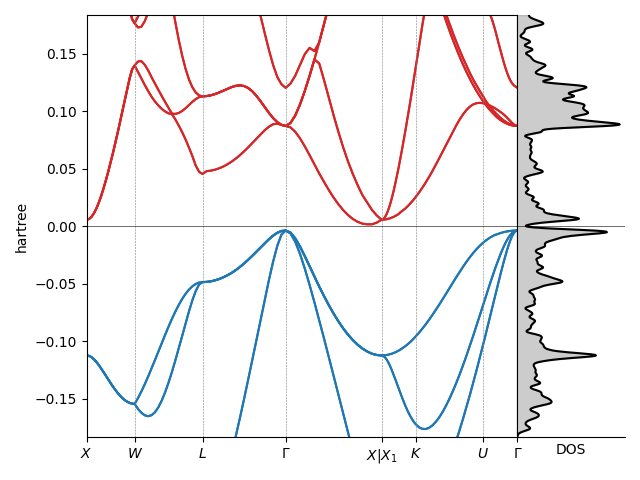

In [20]:
bands=spectrum.ElectronBands('data/qe/results_bands/bands.xml')
bands.kpath=grep.kpath('data/qe/results_bands/Si.bands.pwi')
ax=plot.bandsDOS(bands,
           window=[-5,5]*ureg.eV)

### Multiple band structures

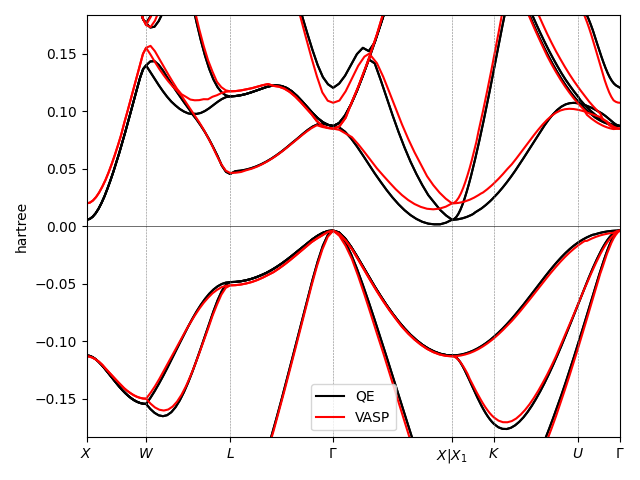

In [10]:
b1=spectrum.ElectronBands('data/qe/results_bands/bands.xml')
b1.kpath=grep.kpath('data/qe/results_bands/Si.bands.pwi')
b2=spectrum.ElectronBands('data/vasp/RESULTS/OUTCAR_BS')
b2.kpath=grep.kpath('data/vasp/KPATH')
ax=plot.bands([b1,b2],
           window=[-5,5]*ureg.eV,
           labels=['QE','VASP'],
           colors=['black','red'])

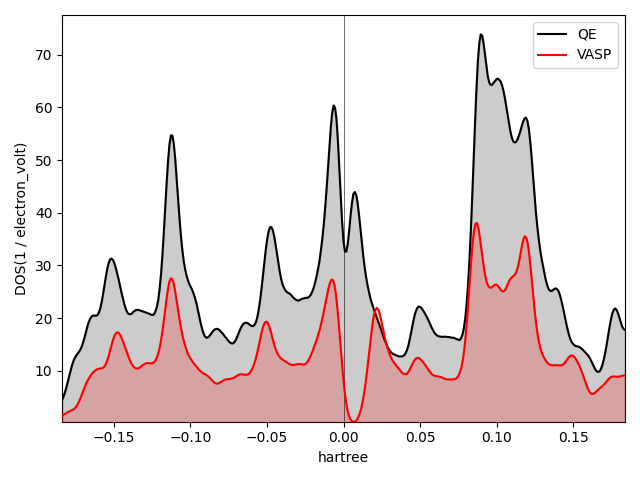

In [31]:
b1=spectrum.ElectronBands('data/qe/results_bands/bands.xml')
b2=spectrum.ElectronBands('data/vasp/RESULTS/OUTCAR_BS')
ax=plot.DOS([b1,b2],
           window=[-5,5]*ureg.eV,
           labels=['QE','VASP'],
           colors=['black','red'],
           smearing=100*ureg.meV)

/u/51/gutierm2/unix/Software/YAIV/build/__editable__.yaiv-1.0.8-py3-none-any/yaiv/plot.py:655: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = fig or plt.figure()


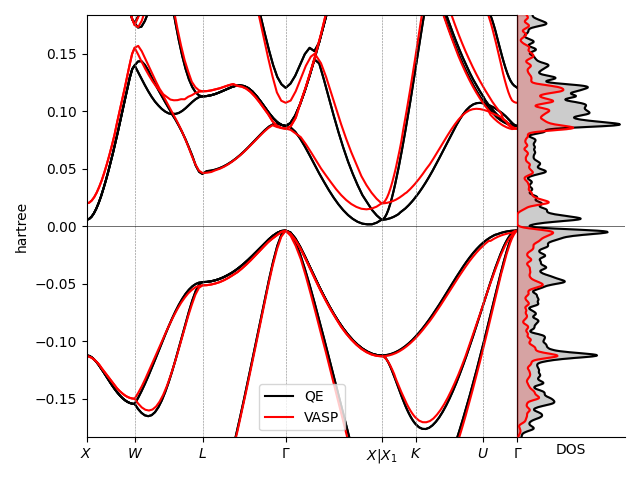

In [32]:
b1=spectrum.ElectronBands('data/qe/results_bands/bands.xml')
b1.kpath=grep.kpath('data/qe/results_bands/Si.bands.pwi')
b2=spectrum.ElectronBands('data/vasp/RESULTS/OUTCAR_BS')
b2.kpath=grep.kpath('data/vasp/KPATH')
ax=plot.bandsDOS([b1,b2],
           window=[-5,5]*ureg.eV,
           labels=['QE','VASP'],
           colors=['black','red'])

### Orbital projecions

In [29]:
bands.eigenvalues.shape

(140, 8)

In [30]:
bands.kpoints.shape

(140, 3)

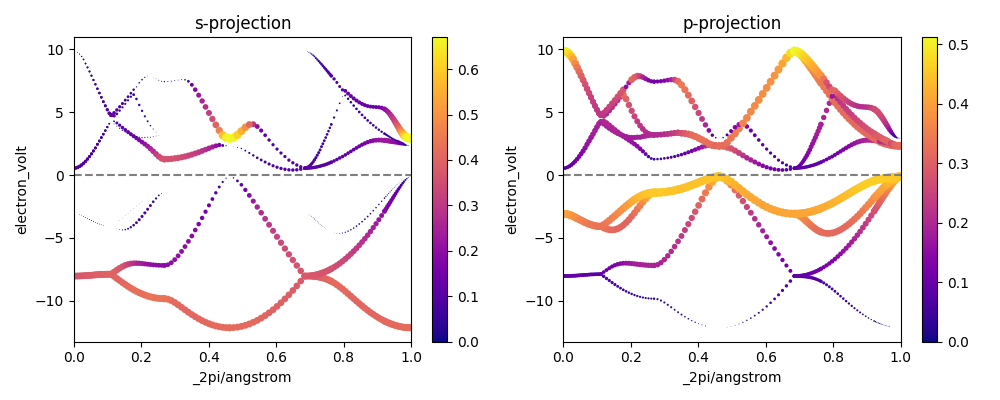

In [109]:
bands=spectrum.ElectronBands('data/vasp/RESULTS/OUTCAR_BS')
bands.kpath=grep.kpath('data/vasp/RESULTS/KPATH')
projections=grep.kpointsEnergies('data/vasp/RESULTS/PROCAR')

fig,ax = plt.subplots(1,2,figsize=(10,4))
x,scatter=bands.plot_fat(weights=projections.projections(l=0),
               ax=ax[0],
               shift=bands.fermi,
               size_change=True)
x.set_title('s-projection')
plt.colorbar(scatter)
x,scatter=bands.plot_fat(weights=projections.projections(l=1),
               ax=ax[1],
               shift=bands.fermi,
               size_change=True)
x.set_title('p-projection')
plt.colorbar(scatter)
for x in ax:
    x.axhline(0,linestyle='--',color='gray')
plt.tight_layout()
plt.show()

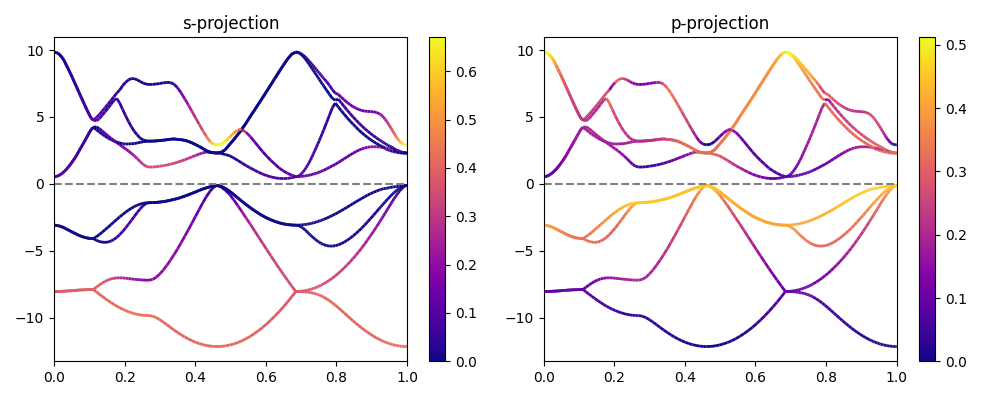

In [110]:
bands=spectrum.ElectronBands('data/vasp/RESULTS/OUTCAR_BS')
bands.kpath=grep.kpath('data/vasp/RESULTS/KPATH')
projections=grep.kpointsEnergies('data/vasp/RESULTS/PROCAR')

fig,ax = plt.subplots(1,2,figsize=(10,4))
x,scatter=bands.plot_color(weights=projections.projections(l=0),
               ax=ax[0],
               shift=bands.fermi)
x.set_title('s-projection')
plt.colorbar(scatter)
x,scatter=bands.plot_color(weights=projections.projections(l=1),
               ax=ax[1],
               shift=bands.fermi)
x.set_title('p-projection')
plt.colorbar(scatter)
for x in ax:
    x.axhline(0,linestyle='--',color='gray')
plt.tight_layout()
plt.show()

## Phonon bands

In [42]:
from yaiv import plot
from yaiv import spectrum
import matplotlib.pyplot as plt

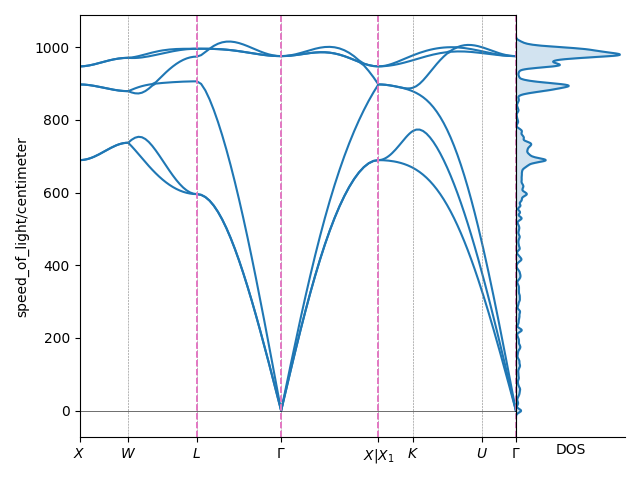

In [13]:
phonons=spectrum.PhononBands('data/qe/results_matdyn/Si.freq')
phonons.lattice=grep.lattice('data/qe/results_scf/scf.xml')
phonons.kpath=grep.kpath('data/qe/results_matdyn/matdyn.in')
ax=plot.phononsDOS(phonons,
                grid=[2,2,2], # This flag highlights your grid points in your path.
                )

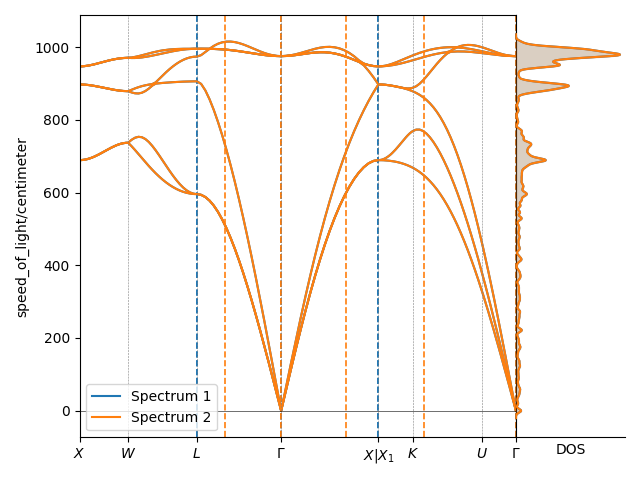

In [19]:
phonons=spectrum.PhononBands('data/qe/results_matdyn/Si.freq')
phonons.lattice=grep.lattice('data/qe/results_scf/scf.xml')
phonons.kpath=grep.kpath('data/qe/results_matdyn/matdyn.in')
ax=plot.phononsDOS([phonons,phonons],
                   grid=[[2,2,2],[3,3,3]], # You can compare different grids.
                   )